In [ ]:
"""
Project roadmap (reminder for future self)

1. Data merge (Compustat + CRSP)
   - Load `dividend_buyback_data.csv` and `crspdata.csv`.
   - Trim CUSIP to 8 digits, convert both dates to monthly period-ends, and merge on CUSIP/month.
   - Diagnose duplicate gvkey/permno pairs to confirm the match quality.

2. Payout metrics
   - Turn `prstkc` into positive buyback dollars and pair with dividends.
   - Build payout ratios vs net income and market cap; clip outliers.
   - Classify firms into buyback-dominant, dividend-dominant, mixed, or no-payout buckets.

3. Forward returns
   - Sort by PERMNO/month and create 12-, 24-, and 36-month buy-and-hold returns using log-return arithmetic.

4. Portfolio analysis
   - Equal-weight and value-weight forward returns by payout group.
   - Summaries of average performance across horizons.

5. Factor adjustments
   - Load Fama–French 5 (plus momentum) factors, align them to month-end.
   - Regression of buyback-minus-dividend spreads on the factors to obtain risk-adjusted alphas (EW and VW).

6. Visualization
   - Plot cumulative excess returns for buyback-minus-dividend spreads to see time-series dynamics.

7. Cross-sectional checks (optional)
   - Set up Fama–MacBeth style regressions with buyback dummy, size, and profitability to test firm-level predictors of future returns.

Next: interpret the regression outputs, alphas, and cumulative plots; decide whether more data (additional fundamentals or longer history) is needed for robustness.
"""

"""10/28/2025 
-Created most of the code 
- I have a few concerns with the outputs, starting that the equal and 
value weight average forward returns. The returns for the mixed type are 
much larger thatn the buyback or the dividende reutnrs, why? and they don't
 have 36m forward returns why? also what does the regression tell us. Further 
 the graph taht you produce is near zero for most of the time that spikes in 
 2000 to insane levels, why is this?

 -Answer:

Mixed Portfolio Jumping Ahead

Mixed firms balloon because the “mixed” bucket is tiny and often contains observations with very small total payouts (a $1 buyback + $1 dividend still counts as mixed). When total payouts are small, the forward-return averages become dominated by a handful of firms, so one outsized winner can pull the mean way above buyback/dividend groups. Tightening the dominance rule (raise policy_threshold or drop firms with total payouts below, say, $10 M) or requiring a minimum firm count per month before averaging will tame that effect.
Missing 36 Month Forwards

The forward-return helper only populates a value when it has the full window of data after month t. If your CRSP file ends in, for example, 2021, then anything from 2019 onward lacks the 36 subsequent monthly returns and shows up as NaN. Extending the return history or switching to a shorter horizon fixes it.
Reading the Factor Regression

The intercept (const) is the monthly alpha of buyback-versus-dividend after adjusting for the Fama French factors (and momentum if included). A positive, statistically significant alpha means buyback-dominant portfolios are outperforming dividend-dominant portfolios on a risk-adjusted basis. If the t-stat is weak or negative, the spread isn t delivering abnormal performance once common risk exposures are accounted for.
Cumulative Spread Spiking in 2000

That blow-up indicates a small number of months (possibly oly one) with huge spread returns—usually because the under lying monthly panel has very few firms early on. The curve sits near zero when buyback and dividend portfolios move together, then one big outlier around 2000 multiplies the cumulative excess (we re compounding (1 + excess) each month). Inspect the monthly panel around that date to check sample sizes; you can cap extreme spreads, require at least a minimum firm count per month, or start the plot once both groups have enough coverage.
Next Moves

Filter out months with fewer than a chosen number of firms in each payout group before computing portfolio returns.
Raise the dominance cutoff or exclude “mixed” firms with total payouts below a dollar threshold so the category represents meaningful split policies.
Clip extreme monthly spreads or winsorize returns before building cumulative curves, then revisit the factor regressions with the cleaned sample.

"""



'\nProject roadmap (reminder for future self)\n\n1. Data merge (Compustat + CRSP)\n   - Load `dividend_buyback_data.csv` and `crspdata.csv`.\n   - Trim CUSIP to 8 digits, convert both dates to monthly period-ends, and merge on CUSIP/month.\n   - Diagnose duplicate gvkey/permno pairs to confirm the match quality.\n\n2. Payout metrics\n   - Turn `prstkc` into positive buyback dollars and pair with dividends.\n   - Build payout ratios vs net income and market cap; clip outliers.\n   - Classify firms into buyback-dominant, dividend-dominant, mixed, or no-payout buckets.\n\n3. Forward returns\n   - Sort by PERMNO/month and create 12-, 24-, and 36-month buy-and-hold returns using log-return arithmetic.\n\n4. Portfolio analysis\n   - Equal-weight and value-weight forward returns by payout group.\n   - Summaries of average performance across horizons.\n\n5. Factor adjustments\n   - Load Fama–French 5 (plus momentum) factors, align them to month-end.\n   - Regression of buyback-minus-dividend s

In [37]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../") / "FinalProject_Dividend_ShareBuyBack"  # adjust if the notebook sits elsewhere

# --- load raw files
comp = pd.read_csv(DATA_DIR / "dividend_butback_dataall.csv", parse_dates=["datadate"])
crsp = pd.read_csv(DATA_DIR / "crspdata_all.csv", parse_dates=["date"])

# --- prepare merge keys
comp["cusip8"] = comp["cusip"].str.slice(0, 8)
crsp["cusip8"] = crsp["CUSIP"].astype(str).str.slice(0, 8)

comp["month"] = comp["datadate"].dt.to_period("M").dt.to_timestamp("M")
crsp["month"] = crsp["date"].dt.to_period("M").dt.to_timestamp("M")

# optional: keep only profitable years if you plan to drop negatives later
# comp = comp[comp["ni"] > 0]

# --- merge
merged = pd.merge(
    comp,
    crsp,
    on=["cusip8", "month"],
    how="inner",
    suffixes=("_comp", "_crsp"),
)

# --- quick diagnostics
print(f"Compustat rows: {len(comp):,}")
print(f"CRSP rows:      {len(crsp):,}")
print(f"Merged rows:    {len(merged):,}\n")

print("Sample merged rows:")
display(
    merged.loc[:, ["tic", "PERMNO", "cusip8", "month", "dvc", "prstkc", "PRC", "RET"]]
          .head(10)
)

# check for firms with multiple PERMNOs or GVKEYs on the same key
dup = (
    merged
    .groupby(["cusip8", "month"])
    .agg(
        gvkey_count=("gvkey", "nunique"),
        permno_count=("PERMNO", "nunique"),
    )
)
problem_keys = dup[(dup["gvkey_count"] > 1) | (dup["permno_count"] > 1)]
print(f"Keys with multiple firm ids: {len(problem_keys)}")
if not problem_keys.empty:
    display(problem_keys.head())



Compustat rows: 517,796
CRSP rows:      3,903,923
Merged rows:    310,944

Sample merged rows:


,tic,PERMNO,cusip8,month,dvc,prstkc,PRC,RET
0,ANTQ,10031,00035410,1983-12-31,0.000,1.200,-5.3750,C
1,AMFD.,10015,00016510,1983-12-31,0.000,0.000,-7.5000,-0.076923
2,AMFD.,10015,00016510,1984-12-31,0.000,0.000,-3.8125,0.033898
3,AMFD.,10015,00016510,1985-12-31,0.000,0.009,10.1250,0.065789
4,ANTQ,10031,00035410,1984-12-31,0.000,0.000,-3.0000,0.142857
5,ANTQ,10031,00035410,1986-01-31,0.000,0.000,-4.7500,0.013333
6,ANTQ,10031,00035410,1987-01-31,0.000,0.000,-4.6875,0.041667
7,ANTQ,10031,00035410,1988-01-31,0.000,0.000,-3.1250,0.000000
8,ANTQ,10031,00035410,1989-01-31,0.000,0.000,-2.0000,0.000000
9,AIR,54594,00036110,1982-05-31,1.582,0.518,7.0000,0.000000


Keys with multiple firm ids: 0


In [38]:
import numpy as np

# --- build payout metrics on the merged panel
merged = merged.assign(
    # make repurchases positive (Compustat stores treasury stock purchases as negative cash flow)
    buyback_dollars = -merged["prstkc"].fillna(0.0),
    dividend_dollars = merged["dvc"].fillna(0.0),
    total_payouts = lambda df: df["buyback_dollars"] + df["dividend_dollars"],
    net_income = merged["ni"],
    shares_out = merged["SHROUT"] * 1_000,  # CRSP reports in thousands
    market_cap = merged["PRC"].abs() * merged["SHROUT"] * 1_000,
)

# avoid divide-by-zero later
merged.loc[merged["market_cap"] == 0, "market_cap"] = np.nan

# --- payout intensity ratios
merged = merged.assign(
    buyback_to_income = merged["buyback_dollars"] / merged["net_income"],
    dividend_to_income = merged["dividend_dollars"] / merged["net_income"],
    buyback_to_mktcap = merged["buyback_dollars"] / merged["market_cap"],
    dividend_to_mktcap = merged["dividend_dollars"] / merged["market_cap"],
)

# clip extreme ratios to reasonable bounds (e.g., +/- 5) to tame outliers; tweak as needed
ratio_cols = ["buyback_to_income", "dividend_to_income", "buyback_to_mktcap", "dividend_to_mktcap"]
merged[ratio_cols] = merged[ratio_cols].clip(-5, 5)

# --- classify payout policy
merged = merged.assign(
    buyback_share = merged["buyback_dollars"] / merged["total_payouts"],
    dividend_share = merged["dividend_dollars"] / merged["total_payouts"],
)

policy_threshold = 0.75  # change if you want a stricter cutoff, determines if they are dominate in one payout type (if 60% or more of total payouts are one type, they are dominant in that)



merged["payout_type"] = np.select(
    [
        merged["total_payouts"] <= 0,
        merged["buyback_share"] >= policy_threshold,
        merged["dividend_share"] >= policy_threshold,
    ],
    [
        "no_payout",
        "buyback_dominant",
        "dividend_dominant",
    ],
    default="mixed",
)

print(merged[["tic", "month", "buyback_dollars", "dividend_dollars",
              "buyback_to_income", "dividend_to_income",
              "buyback_to_mktcap", "dividend_to_mktcap",
              "payout_type"]].head(10))


     tic      month  buyback_dollars  dividend_dollars  buyback_to_income  \
0   ANTQ 1983-12-31           -1.200             0.000          -1.142857   
1  AMFD. 1983-12-31           -0.000             0.000          -0.000000   
2  AMFD. 1984-12-31           -0.000             0.000          -0.000000   
3  AMFD. 1985-12-31           -0.009             0.000          -0.003494   
4   ANTQ 1984-12-31           -0.000             0.000          -0.000000   
5   ANTQ 1986-01-31           -0.000             0.000          -0.000000   
6   ANTQ 1987-01-31           -0.000             0.000          -0.000000   
7   ANTQ 1988-01-31           -0.000             0.000          -0.000000   
8   ANTQ 1989-01-31           -0.000             0.000           0.000000   
9    AIR 1982-05-31           -0.518             1.582          -0.422857   

   dividend_to_income  buyback_to_mktcap  dividend_to_mktcap  \
0            0.000000      -8.321126e-08        0.000000e+00   
1            0.000000   

In [46]:
"""New code 

This tightens the criteria for classifying firms into payout types by introducing a dominance threshold and a 
minimum total payout requirement. Firms must have a significant portion of their payouts from one channel (buybacks or dividends) 
to be classified as dominant, otherwise they are labeled as mixed. Additionally, firms with very low total payouts are categorized 
separately to avoid skewing the analysis with insignificant data.
"""
import numpy as np

# tune these knobs as needed
DOMINANCE_THRESHOLD = 0.70   # % of total payouts that must come from one channel to be "dominant"
MIN_TOTAL_PAYOUT = 1_000_000 # skip firms with less than $1m combined dividends+buybacks in a month

merged = merged.assign(
    buyback_dollars = -merged["prstkc"].fillna(0.0),
    dividend_dollars = merged["dvc"].fillna(0.0),
)

merged = merged.assign(
    total_payouts = merged["buyback_dollars"] + merged["dividend_dollars"],
    eligible_payout = merged["total_payouts"] >= MIN_TOTAL_PAYOUT,
)

merged = merged.assign(
    buyback_share = merged["buyback_dollars"] / merged["total_payouts"],
    dividend_share = merged["dividend_dollars"] / merged["total_payouts"],
)

def classify_row(row):
    if (row["total_payouts"] <= 0) or (not row["eligible_payout"]):
        return "low_payout"
    if row["buyback_share"] >= DOMINANCE_THRESHOLD:
        return "buyback_dominant"
    if row["dividend_share"] >= DOMINANCE_THRESHOLD:
        return "dividend_dominant"
    return "mixed"

merged["payout_type"] = merged.apply(classify_row, axis=1)


In [47]:
import numpy as np

# ensure monthly returns are numeric and sorted
merged["RET"] = pd.to_numeric(merged["RET"], errors="coerce")
merged = merged.sort_values(["PERMNO", "month"]).reset_index(drop=True)

def forward_buy_and_hold(df, col, horizon):
    """
    Computes the compound return from t+1 through t+horizon for each PERMNO.
    Uses log returns so the math works even with negative values.
    """
    def _calc(series):
        log_r = np.log1p(series)
        fwd_log = (
            log_r.shift(-1)                                  # start at next month
                 .rolling(window=horizon, min_periods=horizon)
                 .sum()
                 .shift(-(horizon - 1))                      # align back to current month
        )
        return np.expm1(fwd_log)
    return (
        df.groupby("PERMNO", group_keys=False)[col]
          .apply(_calc)
    )

merged["forward_ret_12m"] = forward_buy_and_hold(merged, "RET", 12)
merged["forward_ret_24m"] = forward_buy_and_hold(merged, "RET", 24)
merged["forward_ret_36m"] = forward_buy_and_hold(merged, "RET", 36)

# quick peek at the enriched panel
display(
    merged.loc[merged["forward_ret_12m"].notna(),
               ["tic", "PERMNO", "month", "RET",
                "forward_ret_12m", "forward_ret_24m", "forward_ret_36m",
                "payout_type"]].head(10)
)


,tic,PERMNO,month,RET,forward_ret_12m,forward_ret_24m,forward_ret_36m,payout_type
1,EGAS,10001,1986-06-30,-0.013069,0.360083,0.625117,NaN,low_payout
2,EGAS,10001,1987-06-30,0.051429,0.302119,0.625745,NaN,low_payout
3,EGAS,10001,1988-06-30,-0.012039,0.354452,0.620492,NaN,low_payout
4,EGAS,10001,1989-06-30,0.017143,0.484698,0.499409,NaN,low_payout
5,EGAS,10001,1990-06-30,0.014103,0.428890,0.422629,NaN,low_payout
6,EGAS,10001,1991-06-30,0.078481,-0.056552,0.144783,NaN,low_payout
7,EGAS,10001,1992-06-30,-0.007708,-0.039124,0.165213,NaN,low_payout
8,EGAS,10001,1993-06-30,0.102479,-0.016507,NaN,NaN,low_payout
9,EGAS,10001,1994-06-30,0.107302,-0.179658,NaN,NaN,low_payout
10,EGAS,10001,1995-06-30,0.060317,-0.225807,NaN,NaN,low_payout


In [55]:
"""

OLD CODE 

# restrict to observations with a payout tag, valid forward returns, and positive market cap
analysis_sample = merged.loc[
    merged["payout_type"].isin(["buyback_dominant", "dividend_dominant", "mixed"]) &
    merged["forward_ret_12m"].notna() &
    (merged["market_cap"] > 0)
].copy()

horizons = [12, 24, 36]

# equal-weight portfolio returns by month and payout type
ew_panel = (
    analysis_sample
    .groupby(["month", "payout_type"])[[f"forward_ret_{h}m" for h in horizons]]
    .mean()
    .rename(columns={f"forward_ret_{h}m": f"ew_ret_{h}m" for h in horizons})
    .reset_index()
)

def value_weighted_return(df, return_col, weight_col="market_cap"):
    valid = df[[return_col, weight_col]].dropna()
    if valid.empty:
        return np.nan
    weights = valid[weight_col]
    return np.sum(valid[return_col] * weights) / weights.sum()

# value-weighted portfolio returns by month and payout type
vw_panel = (
    analysis_sample
    .groupby(["month", "payout_type"])
    .apply(lambda df: pd.Series(
        {f"vw_ret_{h}m": value_weighted_return(df, f"forward_ret_{h}m") for h in horizons}
    ))
    .reset_index()
)

# average performance over time
ew_summary = (
    ew_panel.groupby("payout_type")[[f"ew_ret_{h}m" for h in horizons]]
    .mean()
    .sort_values(by="ew_ret_12m", ascending=False)
)

vw_summary = (
    vw_panel.groupby("payout_type")[[f"vw_ret_{h}m" for h in horizons]]
    .mean()
    .sort_values(by="vw_ret_12m", ascending=False)
)

print("Equal-weight average forward returns:")
display(ew_summary)

print("Value-weight average forward returns:")
display(vw_summary)
"""

MIN_FIRMS_PER_GROUP = 5
TARGET_TYPES = ["buyback_dominant", "dividend_dominant"]
HORIZONS = [12, 24, 36]

forward_cols = [f"forward_ret_{h}m" for h in HORIZONS]

analysis_sample = merged.loc[
    merged["payout_type"].isin(TARGET_TYPES)
    & (merged["market_cap"] > 0)
    & merged["forward_ret_12m"].notna()
].copy()

analysis_sample = analysis_sample.reset_index(drop=True)

for col in forward_cols:
    if col in analysis_sample:
        analysis_sample[col] = pd.to_numeric(analysis_sample[col], errors="coerce")

# keep months where each dominant group has enough firms
counts = (
    analysis_sample.groupby(["month", "payout_type"]).size()
    .unstack(fill_value=0)
    .reindex(columns=TARGET_TYPES, fill_value=0)
)
valid_months = counts.index[
    (counts[TARGET_TYPES[0]] >= MIN_FIRMS_PER_GROUP)
    & (counts[TARGET_TYPES[1]] >= MIN_FIRMS_PER_GROUP)
]
analysis_sample = analysis_sample[analysis_sample["month"].isin(valid_months)].reset_index(drop=True)

# winsorize within month to clip extremes
for col in forward_cols:
    lower = analysis_sample.groupby("month")[col].transform(lambda s: s.quantile(0.01))
    upper = analysis_sample.groupby("month")[col].transform(lambda s: s.quantile(0.99))
    analysis_sample[col] = analysis_sample[col].clip(lower, upper)

# equal-weight monthly returns
ew_panel = (
    analysis_sample.groupby(["month", "payout_type"])[forward_cols]
    .mean()
    .rename(columns=lambda c: c.replace("forward_", "ew_"))
    .reset_index()
)

def vw_monthly(df):
    out = {}
    weights = df["market_cap"]
    weight_sum = weights.sum()
    for col in forward_cols:
        col_data = df[[col, "market_cap"]].dropna()
        if col_data.empty or col_data["market_cap"].sum() <= 0:
            out[col.replace("forward_", "vw_")] = np.nan
        else:
            out[col.replace("forward_", "vw_")] = np.average(col_data[col], weights=col_data["market_cap"])
    return pd.Series(out)

vw_panel = (
    analysis_sample.groupby(["month", "payout_type"])
    .apply(vw_monthly)
    .reset_index()
)

ew_cols = [c for c in ew_panel.columns if c.startswith("ew_ret_")]
vw_cols = [c for c in vw_panel.columns if c.startswith("vw_ret_")]

ew_summary = (
    ew_panel.groupby("payout_type")[ew_cols]
            .mean()
            .sort_values("ew_ret_12m", ascending=False)
)
vw_summary = (
    vw_panel.groupby("payout_type")[vw_cols]
            .mean()
            .sort_values("vw_ret_12m", ascending=False)
)

display(ew_summary)
display(vw_summary)




/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_23993/305205142.py:117: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analysis_sample.groupby(["month", "payout_type"])


ValueError: cannot insert payout_type, already exists

In [41]:
# paths to the CSVs you just dropped into FinalProject_Dividend_ShareBuyBack/
FF5_PATH = "/Users/owenbrown/Desktop/PythonFolder/FIN342/FinalProject_Dividend_ShareBuyBack/F-F_Research_Data_5_Factors_2x3_daily.csv"

def load_ff5(path):
    raw = pd.read_csv(path, skiprows=3)
    raw = raw.rename(columns={raw.columns[0]: "date"})
    raw["date"] = raw["date"].astype(str).str.strip()
    raw = raw[raw["date"].str.isdigit()]              # drop header/footer rows
    raw["date"] = raw["date"].str.slice(0, 6)         # keep YYYYMM
    raw["date"] = pd.to_datetime(raw["date"], format="%Y%m")
    factors = raw.set_index("date").astype(float) / 100.0
    factors.columns = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]
    return factors


def load_mom(path):
    raw = pd.read_csv(path, skiprows=13)
    raw = raw.rename(columns={raw.columns[0]: "date", raw.columns[1]: "UMD"})
    raw = raw[raw["date"].astype(str).str.strip().str.isdigit()]
    raw["date"] = pd.to_datetime(raw["date"].astype(str), format="%Y%m")
    return raw.set_index("date").astype(float) / 100.0

ff5 = load_ff5(FF5_PATH)

try:
    mom = load_mom(MOM_PATH)
    factors = ff5.join(mom, how="left")
except FileNotFoundError:
    factors = ff5.copy()
    print("Momentum CSV not found; continuing without UMD.")

# right after you build `factors`
factors.index = factors.index.to_period("M").to_timestamp("M")  # shift to month-end dates

factors.head()


Momentum CSV not found; continuing without UMD.


,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,
1963-07-31,-0.0067,0.0000,-0.0034,-0.0001,0.0016,0.0001
1963-07-31,0.0079,-0.0026,0.0026,-0.0007,-0.0020,0.0001
1963-07-31,0.0063,-0.0017,-0.0009,0.0018,-0.0034,0.0001
1963-07-31,0.0040,0.0008,-0.0027,0.0009,-0.0034,0.0001
1963-07-31,-0.0063,0.0004,-0.0018,-0.0029,0.0014,0.0001


In [42]:
import statsmodels.api as sm

# monthly equal-weight returns for the two groups
monthly_panel = (
    merged.loc[merged["payout_type"].isin(["buyback_dominant", "dividend_dominant"])]
          .groupby(["month", "payout_type"])["RET"]
          .mean()
          .unstack("payout_type")
)

monthly_panel["spread"] = (
    monthly_panel["buyback_dominant"] - monthly_panel["dividend_dominant"]
)

# align with factors and form excess returns
analysis = monthly_panel.join(factors, how="inner")

for col in ["buyback_dominant", "dividend_dominant", "spread"]:
    analysis[f"{col}_excess"] = analysis[col] - analysis["RF"]

target = "spread_excess"  # flip to 'buyback_dominant_excess' or 'dividend_dominant_excess' if you want individual alphas

X_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
if "UMD" in analysis.columns:
    X_cols.append("UMD")

X = sm.add_constant(analysis[X_cols])
y = analysis[target]

model = sm.OLS(y, X, missing="drop").fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          spread_excess   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.1457
Date:                Tue, 28 Oct 2025   Prob (F-statistic):              0.981
Time:                        12:28:57   Log-Likelihood:                -26.080
No. Observations:                 581   AIC:                             64.16
Df Residuals:                     575   BIC:                             90.35
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0631      0.011      5.853      0.0

In [43]:
# value-weighted monthly returns by payout type
vw_monthly = (
    merged.loc[merged["payout_type"].isin(["buyback_dominant", "dividend_dominant"]) & (merged["market_cap"] > 0)]
          .groupby(["month", "payout_type"])
          .apply(lambda df: np.sum(df["RET"] * df["market_cap"]) / df["market_cap"].sum())
          .unstack("payout_type")
          .rename(columns={"buyback_dominant": "vw_buyback", "dividend_dominant": "vw_dividend"})
)

vw_monthly["vw_spread"] = vw_monthly["vw_buyback"] - vw_monthly["vw_dividend"]

vw_analysis = vw_monthly.join(factors, how="inner")
for col in ["vw_buyback", "vw_dividend", "vw_spread"]:
    vw_analysis[f"{col}_excess"] = vw_analysis[col] - vw_analysis["RF"]

target = "vw_spread_excess"  # switch if you want individual alphas
X = sm.add_constant(vw_analysis[X_cols])  # X_cols already defined in the previous cell
y = vw_analysis[target]

vw_model = sm.OLS(y, X, missing="drop").fit()
print(vw_model.summary())

# annualize the spread alpha for an easy interpretation
monthly_alpha = vw_model.params["const"]
annual_alpha = (1 + monthly_alpha) ** 12 - 1
print(f"Value-weighted spread alpha (annualized): {annual_alpha:.4%}")


                            OLS Regression Results                            
Dep. Variable:       vw_spread_excess   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.2183
Date:                Tue, 28 Oct 2025   Prob (F-statistic):              0.955
Time:                        12:28:57   Log-Likelihood:                -30.071
No. Observations:                 581   AIC:                             72.14
Df Residuals:                     575   BIC:                             98.33
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0653      0.011      6.011      0.0

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_23993/2755873625.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged.loc[merged["payout_type"].isin(["buyback_dominant", "dividend_dominant"]) & (merged["market_cap"] > 0)]


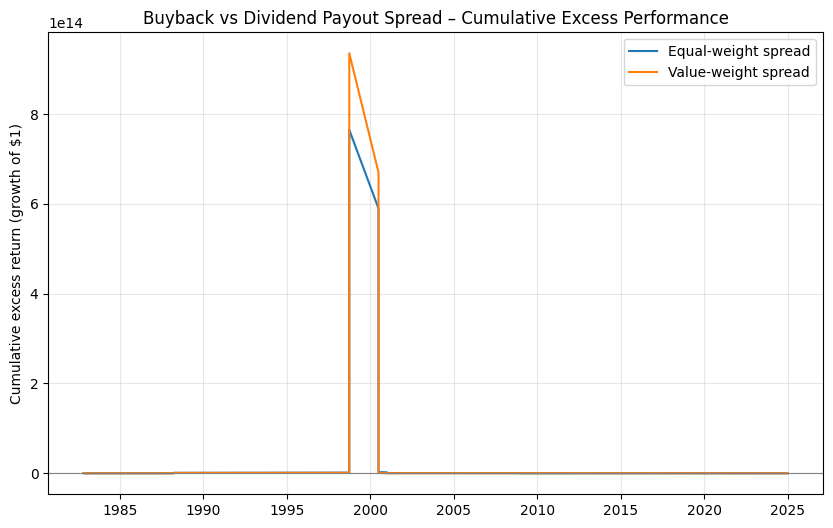

In [44]:
import matplotlib.pyplot as plt

def cumulative_excess(panel, spread_col, rf_col="RF"):
    df = panel[[spread_col, rf_col]].dropna().copy()
    df["excess"] = df[spread_col] - df[rf_col]
    df["cum_excess"] = (1 + df["excess"]).cumprod()
    return df

ew_cum = cumulative_excess(analysis, "spread")          # equal-weight panel from earlier
vw_cum = cumulative_excess(vw_analysis, "vw_spread")    # value-weight panel from last step

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ew_cum.index, ew_cum["cum_excess"], label="Equal-weight spread")
ax.plot(vw_cum.index, vw_cum["cum_excess"], label="Value-weight spread")
ax.axhline(1.0, color="grey", linewidth=0.8)
ax.set_ylabel("Cumulative excess return (growth of $1)")
ax.set_title("Buyback vs Dividend Payout Spread – Cumulative Excess Performance")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


In [45]:
import statsmodels.api as sm

# focus on observations with needed data
reg_sample = merged.loc[
    merged["forward_ret_12m"].notna() &
    merged["market_cap"].gt(0) &
    merged["net_income"].notna()
].copy()

# construct firm characteristics
reg_sample = reg_sample.assign(
    buyback_dummy = (reg_sample["payout_type"] == "buyback_dominant").astype(int),
    dividend_dummy = (reg_sample["payout_type"] == "dividend_dominant").astype(int),
    mixed_dummy = (reg_sample["payout_type"] == "mixed").astype(int),
    log_mktcap = np.log(reg_sample["market_cap"]),
    profitability = reg_sample["net_income"] / reg_sample["market_cap"],
)

# choose which dividends group to treat as the baseline (drop its dummy)
X_cols = ["buyback_dummy", "mixed_dummy", "log_mktcap", "profitability"]
y_col = "forward_ret_12m"      # swap to 24m/36m if desired

betas = []
for month, panel in reg_sample.groupby("month"):
    panel = panel.dropna(subset=X_cols + [y_col])
    if len(panel) <= len(X_cols):   # need enough obs for a regression
        continue
    X = sm.add_constant(panel[X_cols])
    y = panel[y_col]
    res = sm.OLS(y, X).fit()
    betas.append(res.params)

betas = pd.DataFrame(betas)
coef_mean = betas.mean()
coef_se = betas.std(ddof=1) / np.sqrt(len(betas))
t_stats = coef_mean / coef_se

results = pd.DataFrame({
    "coef": coef_mean,
    "std_err": coef_se,
    "t_stat": t_stats,
    "N_months": len(betas),
})
results


,coef,std_err,t_stat,N_months
const,0.554979,0.071399,7.772941,404
buyback_dummy,-0.002407,0.003809,-0.631799,404
mixed_dummy,0.000696,0.000696,1.000000,404
log_mktcap,-0.020741,0.003334,-6.222112,404
profitability,-140846.808574,84650.720912,-1.663858,404
